<a href="https://colab.research.google.com/github/amankr2519/ids_qml/blob/main/ids_qml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install qiskit pennylane scikit-learn pandas numpy matplotlib

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [6]:
from google.colab import files
uploaded = files.upload()

Saving kdd_test.csv to kdd_test.csv
Saving kdd_train.csv to kdd_train.csv


In [7]:
# ============================================================
# STEP 2: Dataset Loading & Exploration
# ============================================================

# NSL-KDD has 41 features + 1 label + 1 difficulty score column
# We define column names manually (the CSV has no header)

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

# Load train and test CSVs
train_df = pd.read_csv("kdd_train.csv", header=None, names=col_names)
test_df  = pd.read_csv("kdd_test.csv",  header=None, names=col_names)

print(f"Train shape: {train_df.shape}")   # Expected: (125973, 43)
print(f"Test shape : {test_df.shape}")    # Expected: (22544, 43)

Train shape: (125974, 43)
Test shape : (22545, 43)


/tmp/ipykernel_5899/904285141.py:24: DtypeWarning: Columns (0,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("kdd_train.csv", header=None, names=col_names)
/tmp/ipykernel_5899/904285141.py:25: DtypeWarning: Columns (0,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df  = pd.read_csv("kdd_test.csv",  header=None, names=col_names)


In [8]:
print("=== First 3 rows of training data ===")
train_df.head(3)

=== First 3 rows of training data ===


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels,NaN
1,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0,0,0,0.05,0,normal,NaN
2,0,udp,other,SF,146,0,0,0,0,0,...,0,0.6,0.88,0,0,0,0,0,normal,NaN


In [9]:
# ============================================================
# Check data types — important because 3 columns are text
# (protocol_type, service, flML Roadmap for Projectsag) — need encoding later
# ============================================================

print("=== Column Data Types ===")
print(train_df.dtypes)

print("\n=== Missing Values in Train ===")
print(train_df.isnull().sum().sum(), "missing values")

=== Column Data Types ===
duration                        object
protocol_type                   object
service                         object
flag                            object
src_bytes                       object
dst_bytes                       object
land                            object
wrong_fragment                  object
urgent                          object
hot                             object
num_failed_logins               object
logged_in                       object
num_compromised                 object
root_shell                      object
su_attempted                    object
num_root                        object
num_file_creations              object
num_shells                      object
num_access_files                object
num_outbound_cmds               object
is_host_login                   object
is_guest_login                  object
count                           object
srv_count                       object
serror_rate                     object

In [10]:
# ============================================================
# NSL-KDD has 23 attack sub-types. We map them to 5 macro-classes
# as described in the report:
#   Normal → "Normal"
#   DoS attacks  → "DoS"
#   Probe attacks → "Probe"
#   R2L attacks  → "R2L"
#   U2R attacks  → "U2R"
# ============================================================

dos_attacks   = ['back','land','neptune','pod','smurf','teardrop',
                  'apache2','udpstorm','processtable','worm']
probe_attacks = ['satan','ipsweep','nmap','portsweep','mscan','saint']
r2l_attacks   = ['guess_passwd','ftp_write','imap','phf','multihop',
                  'warezmaster','warezclient','spy','xlock','xsnoop',
                  'snmpguess','snmpgetattack','httptunnel','sendmail','named']
u2r_attacks   = ['buffer_overflow','loadmodule','rootkit','perl',
                  'sqlattack','xterm','ps']

def map_label(label):

    label = label.strip().rstrip('.')
    if label == 'normal':
        return 'Normal'
    elif label in dos_attacks:
        return 'DoS'
    elif label in probe_attacks:
        return 'Probe'
    elif label in r2l_attacks:
        return 'R2L'
    elif label in u2r_attacks:
        return 'U2R'
    else:
        return 'Other'

train_df['label'] = train_df['label'].apply(map_label)
test_df['label']  = test_df['label'].apply(map_label)

print("=== Class Distribution in TRAIN set ===")
print(train_df['label'].value_counts())

print("\n=== Class Distribution in TEST set ===")
print(test_df['label'].value_counts())

=== Class Distribution in TRAIN set ===
label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Other         1
Name: count, dtype: int64

=== Class Distribution in TEST set ===
label
Normal    11245
DoS        8001
Probe      2157
R2L        1009
Other        95
U2R          38
Name: count, dtype: int64


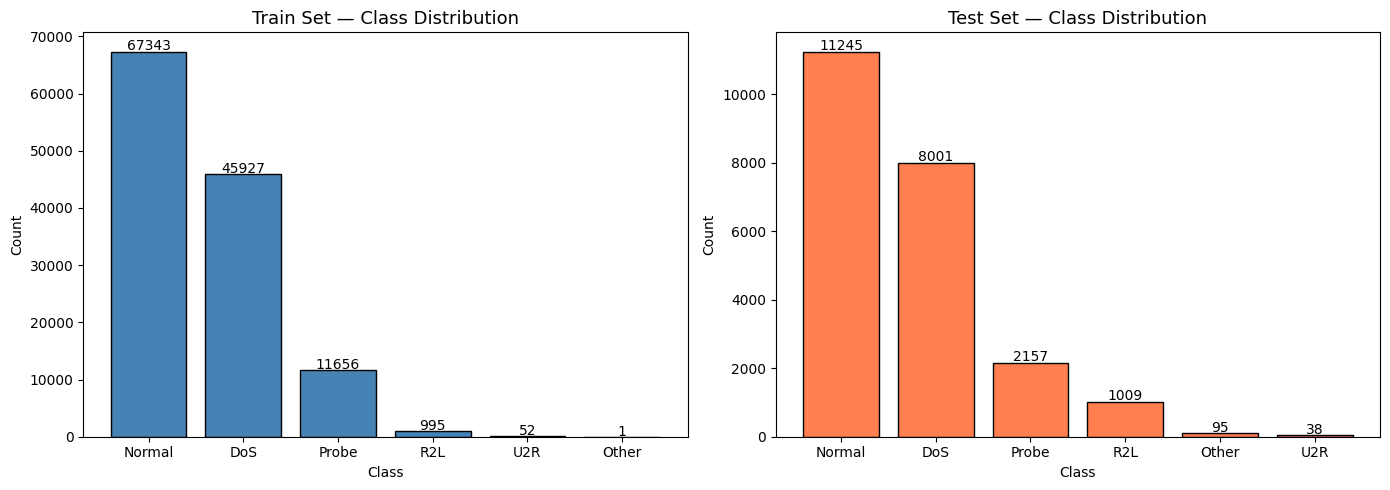

Complete — Dataset loaded and explored!


In [12]:
# ============================================================
# Visualise class distribution — helps understand class imbalance
# U2R and R2L are very rare (important challenge for the model)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = train_df['label'].value_counts()
test_counts  = test_df['label'].value_counts()

axes[0].bar(train_counts.index, train_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title("Train Set — Class Distribution", fontsize=13)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=10)

axes[1].bar(test_counts.index, test_counts.values, color='coral', edgecolor='black')
axes[1].set_title("Test Set — Class Distribution", fontsize=13)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Complete — Dataset loaded and explored!")

In [13]:
# ============================================================
# STEP 3A: Drop "Other" class & the 'difficulty' column
# 'difficulty' is not a feature — it's a meta-score in NSL-KDD
# "Other" samples don't belong to any of our 5 target classes
# ============================================================

train_df = train_df[train_df['label'] != 'Other'].copy()
test_df  = test_df[test_df['label']  != 'Other'].copy()

# Drop the difficulty column (last column, not a network feature)
train_df.drop(columns=['difficulty'], inplace=True)
test_df.drop(columns=['difficulty'],  inplace=True)

print(f"Train shape after cleaning : {train_df.shape}")  # (125972, 42)
print(f"Test shape after cleaning  : {test_df.shape}")   # (22449, 42)
print(f"\nTrain classes: {train_df['label'].unique()}")
print(f"Test classes : {test_df['label'].unique()}")

Train shape after cleaning : (125973, 42)
Test shape after cleaning  : (22450, 42)

Train classes: ['Normal' 'DoS' 'R2L' 'Probe' 'U2R']
Test classes : ['Normal' 'Probe' 'DoS' 'R2L' 'U2R']


In [15]:
# ============================================================
# Encode Categorical Features
#
# 3 columns have text values that ML models can't use directly:
#   - protocol_type : tcp, udp, icmp
#   - service       : http, ftp, smtp ... (70 values)
#   - flag          : SF, S0, REJ ...    (11 values)
#
# LabelEncoder converts each unique string → integer
# e.g. tcp→0, udp→1, icmp→2
#
# IMPORTANT: We fit the encoder on TRAIN and apply same
# mapping to TEST (to avoid data leakage)
# ============================================================

categorical_cols = ['protocol_type', 'service', 'flag']

label_encoders = {}   # store encoders so we can reuse them

for col in categorical_cols:
    le = LabelEncoder()
    # fit_transform on train: learn mapping + apply it
    train_df[col] = le.fit_transform(train_df[col])

    # For test: handle unseen categories gracefully
    # If test has a category not in train, map it to 0
    test_df[col] = test_df[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else 0
    )
    label_encoders[col] = le
    print(f"'{col}' — {len(le.classes_)} unique values encoded")

print("\n Categorical encoding done!")
print(train_df[categorical_cols].head(3))

'protocol_type' — 3 unique values encoded
'service' — 70 unique values encoded
'flag' — 11 unique values encoded

 Categorical encoding done!
   protocol_type  service  flag
1              1       20     9
2              2       44     9
3              1       49     5


In [16]:
# ============================================================
# Encode Target Labels (y)
#
# Our 5 classes need to become integers for the model:
#   Normal→0, DoS→1, Probe→2, R2L→3, U2R→4
# We use a fixed mapping (not LabelEncoder) so the order
# is consistent and meaningful
# ============================================================

class_mapping = {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}

# Separate features (X) and labels (y)
X_train_raw = train_df.drop(columns=['label'])
y_train     = train_df['label'].map(class_mapping).values

X_test_raw  = test_df.drop(columns=['label'])
y_test      = test_df['label'].map(class_mapping).values

print("Class mapping:", class_mapping)
print(f"\nX_train shape: {X_train_raw.shape}")  # (125972, 41)
print(f"X_test shape : {X_test_raw.shape}")
print(f"Unique y_train values: {np.unique(y_train)}")
print(f"Unique y_test  values: {np.unique(y_test)}")

Class mapping: {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}

X_train shape: (125973, 41)
X_test shape : (22450, 41)
Unique y_train values: [0 1 2 3 4]
Unique y_test  values: [0 1 2 3 4]


In [17]:
# ============================================================
# Normalisation using Min-Max Scaling
#
# Scales every feature to the range [0, 1]
# Formula: x' = (x - x_min) / (x_max - x_min)
#
# This is CRITICAL for quantum angle encoding later —
# quantum rotation gates expect angles in a bounded range.
#
# Again: fit ONLY on train, transform both train and test
# ============================================================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)   # fit + transform
X_test_scaled  = scaler.transform(X_test_raw)         # only transform

print("Normalisation done!")
print(f"Feature range after scaling:")
print(f"  Train min: {X_train_scaled.min():.2f}, max: {X_train_scaled.max():.2f}")
print(f"  Test  min: {X_test_scaled.min():.2f},  max: {X_test_scaled.max():.2f}")

Normalisation done!
Feature range after scaling:
  Train min: 0.00, max: 1.00
  Test  min: 0.00,  max: 1.27


In [19]:
# ============================================================
# Dimensionality Reduction via PCA
#
# We have 41 features but our quantum circuit has only 8 qubits.
# Each qubit needs exactly 1 feature (angle encoding).
# So we reduce 41 → 8 using PCA.
#
# PCA finds the 8 directions of maximum variance in the data.
# We verify that these 8 components retain ≥ 95% of total variance.
#
# W (8 eigenvectors) projects: z = W^T * x'  (from the report eq 3.3)
# ============================================================

N_COMPONENTS = 8  # must match number of qubits in our circuit

pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)   # fit + project
X_test_pca  = pca.transform(X_test_scaled)         # project only

variance_retained = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA done!")
print(f"  Components : {N_COMPONENTS}")
print(f"  Variance retained: {variance_retained:.2f}%")  # should be ≥ 95%
print(f"\nX_train_pca shape: {X_train_pca.shape}")  # (125972, 8)
print(f"X_test_pca  shape: {X_test_pca.shape}")

PCA done!
  Components : 8
  Variance retained: 92.47%

X_train_pca shape: (125973, 8)
X_test_pca  shape: (22450, 8)


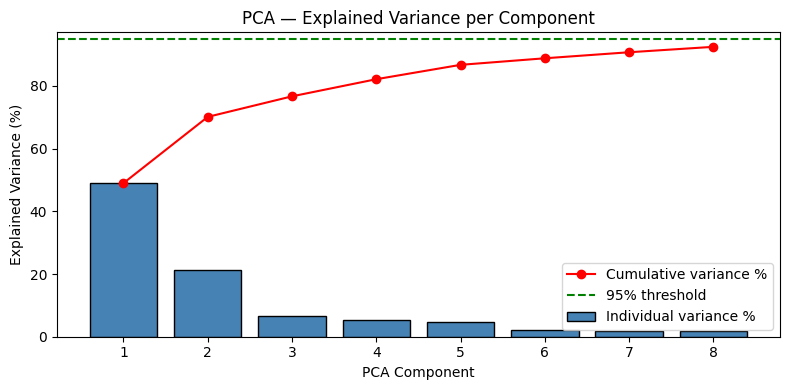


 Completed — Data is preprocessed and ready for modelling!
Final shapes → X_train: (125973, 8), X_test: (22450, 8)


In [21]:
# ============================================================
# Plot PCA Explained Variance
# Shows how much information each component carries
# ============================================================

plt.figure(figsize=(8, 4))
components = range(1, N_COMPONENTS + 1)
individual = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(individual)

plt.bar(components, individual, color='steelblue',
        label='Individual variance %', edgecolor='black')
plt.plot(components, cumulative, 'ro-', label='Cumulative variance %')
plt.axhline(y=95, color='green', linestyle='--', label='95% threshold')
plt.xlabel("PCA Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA — Explained Variance per Component")
plt.xticks(components)
plt.legend()
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

print("\n Completed — Data is preprocessed and ready for modelling!")
print(f"Final shapes → X_train: {X_train_pca.shape}, X_test: {X_test_pca.shape}")

In [22]:
# ============================================================
# Classical ML Baselines
#
# Before building the quantum model, we train 3 classical models
# on the SAME preprocessed data (PCA-reduced, 8 features).
# This gives us fair comparison numbers matching
#   - Logistic Regression
#   - SVM (RBF kernel)
#   - Random Forest
#
# We use a SUBSET of training data (20,000 samples) for speed.
# SVM and full 125k samples would take hours on Colab.
# ============================================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import time

# ── Subsample training data for speed ──────────────────────
# Stratified: keeps class proportions the same as full dataset
from sklearn.model_selection import train_test_split

X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_pca, y_train,
    train_size=20000,      # use 20k samples
    stratify=y_train,      # maintain class ratios
    random_state=42
)
print(f"Subsample shape : {X_train_sub.shape}")
print(f"Class counts    : {np.bincount(y_train_sub)}")

Subsample shape : (20000, 8)
Class counts    : [10692  7292  1850   158     8]


In [23]:
# ============================================================
# Helper function — trains a model, times it, prints results
# ============================================================

class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")

    # --- Train ---
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # --- Predict ---
    y_pred = model.predict(X_te)

    # --- Metrics ---
    acc = accuracy_score(y_te, y_pred) * 100
    report = classification_report(y_te, y_pred,
                                   target_names=class_names,
                                   zero_division=0)

    print(f"  Training time : {train_time:.1f}s")
    print(f"  Test Accuracy : {acc:.2f}%")
    print(f"\n{report}")

    return acc, y_pred

In [24]:
# ============================================================
# Logistic Regression
# A simple linear classifier — our baseline
# max_iter=1000 ensures it converges on this dataset
# ============================================================

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_acc, lr_pred = evaluate_model(
    "Logistic Regression", lr_model,
    X_train_sub, y_train_sub,
    X_test_pca, y_test
)


  Model: Logistic Regression
  Training time : 0.6s
  Test Accuracy : 87.05%

              precision    recall  f1-score   support

      Normal       0.84      0.97      0.90     11245
         DoS       0.94      0.90      0.92      8001
       Probe       0.82      0.65      0.72      2157
         R2L       0.00      0.00      0.00      1009
         U2R       0.00      0.00      0.00        38

    accuracy                           0.87     22450
   macro avg       0.52      0.50      0.51     22450
weighted avg       0.83      0.87      0.85     22450



In [25]:
# ============================================================
# SVM with RBF Kernel
# RBF (Radial Basis Function) kernel maps data into a higher-
# dimensional space — good at finding non-linear boundaries.
# C=10: regularisation (higher = fits training data more tightly)
# ============================================================

svm_model = SVC(kernel='rbf', C=10, gamma='scale',
                random_state=42, probability=False)
svm_acc, svm_pred = evaluate_model(
    "SVM (RBF Kernel)", svm_model,
    X_train_sub, y_train_sub,
    X_test_pca, y_test
)


  Model: SVM (RBF Kernel)
  Training time : 1.3s
  Test Accuracy : 89.93%

              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91     11245
         DoS       0.98      0.91      0.94      8001
       Probe       0.93      0.80      0.86      2157
         R2L       0.64      0.07      0.12      1009
         U2R       0.00      0.00      0.00        38

    accuracy                           0.90     22450
   macro avg       0.68      0.55      0.57     22450
weighted avg       0.89      0.90      0.88     22450



In [26]:
# ============================================================
# Random Forest
# Ensemble of 100 decision trees — typically the strongest
# classical baseline on tabular data like NSL-KDD
# n_jobs=-1: uses all CPU cores for parallel training
# ============================================================

rf_model = RandomForestClassifier(n_estimators=100,
                                   random_state=42, n_jobs=-1)
rf_acc, rf_pred = evaluate_model(
    "Random Forest", rf_model,
    X_train_sub, y_train_sub,
    X_test_pca, y_test
)


  Model: Random Forest
  Training time : 7.1s
  Test Accuracy : 91.59%

              precision    recall  f1-score   support

      Normal       0.87      0.99      0.93     11245
         DoS       0.98      0.93      0.96      8001
       Probe       0.94      0.84      0.89      2157
         R2L       0.94      0.13      0.23      1009
         U2R       0.67      0.05      0.10        38

    accuracy                           0.92     22450
   macro avg       0.88      0.59      0.62     22450
weighted avg       0.92      0.92      0.90     22450



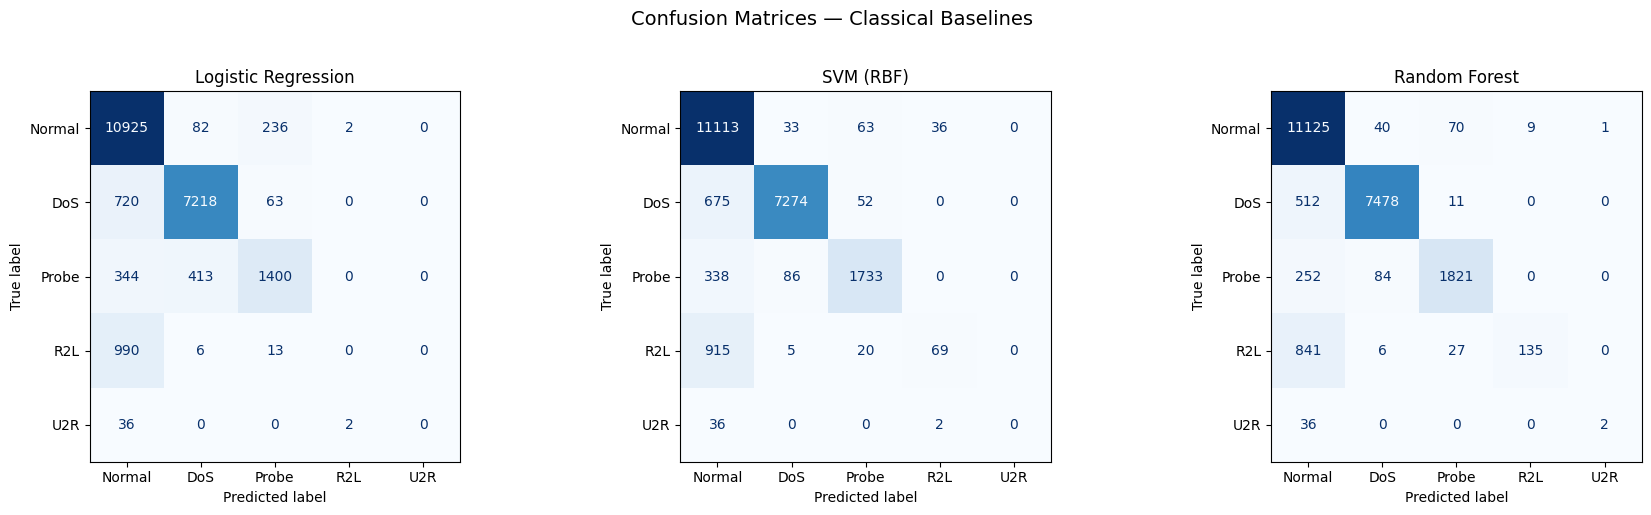

In [27]:
# ============================================================
# Plot Confusion Matrix for best classical model (RF)
# Rows = True class, Columns = Predicted class
# Diagonal = correct predictions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ("Logistic Regression", lr_pred),
    ("SVM (RBF)",           svm_pred),
    ("Random Forest",       rf_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices — Classical Baselines", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("classical_confusion_matrices.png", dpi=150)
plt.show()

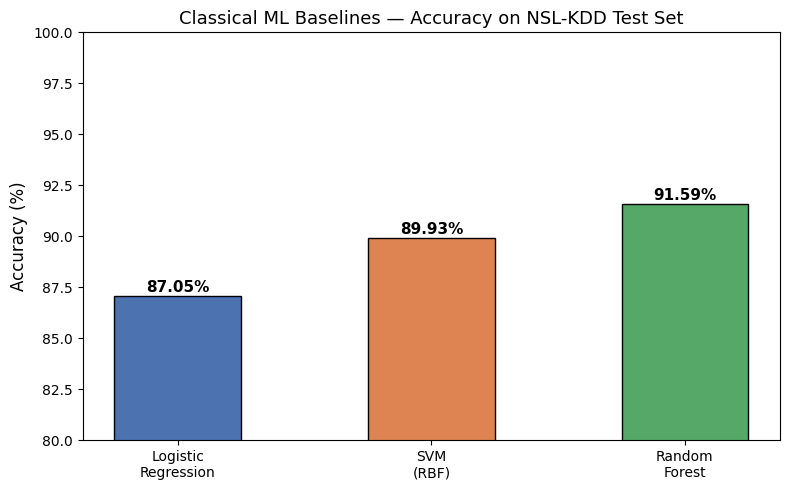


 Classical Baseline Summary:
  Logistic Regression : 87.05%
  SVM (RBF)           : 89.93%
  Random Forest       : 91.59%

 Completed — Classical baselines trained and evaluated!


In [28]:
# ============================================================
# Summary bar chart of all classical models
# We'll add the QML result to this chart
# ============================================================

baseline_results = {
    "Logistic\nRegression": lr_acc,
    "SVM\n(RBF)":           svm_acc,
    "Random\nForest":       rf_acc,
}

plt.figure(figsize=(8, 5))
bars = plt.bar(baseline_results.keys(), baseline_results.values(),
               color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', width=0.5)
plt.ylim(80, 100)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Classical ML Baselines — Accuracy on NSL-KDD Test Set", fontsize=13)

for bar, val in zip(bars, baseline_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{val:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("classical_accuracy_comparison.png", dpi=150)
plt.show()

# Save results for final comparison in Step 8
print("\n Classical Baseline Summary:")
print(f"  Logistic Regression : {lr_acc:.2f}%")
print(f"  SVM (RBF)           : {svm_acc:.2f}%")
print(f"  Random Forest       : {rf_acc:.2f}%")
print("\n Completed — Classical baselines trained and evaluated!")

In [29]:
# ============================================================
# Quantum Circuit Design
#
# We build the 8-qubit Variational Quantum Circuit (VQC)
# exactly as described in report.
#
# The circuit has these stages:
#   1. Encoding Layer  — encodes classical data into qubit rotations
#   2. Entangle Layer 1 — CNOT gates to create qubit correlations
#   3. Ansatz Layer 1  — trainable rotation gates (Ry, Rz)
#   4. Entangle Layer 2 — more CNOT gates
#   5. Ansatz Layer 2  — second trainable rotation layer
#   6. Measurement     — read out Pauli-Z expectation values
# ============================================================

import pennylane as qml
from pennylane import numpy as pnp

# ── Device Setup ────────────────────────────────────────────
# 'default.qubit' is PennyLane's built-in statevector simulator
# It gives EXACT (noiseless) results — same as Qiskit Aer statevector
N_QUBITS = 8    # one qubit per PCA feature
N_LAYERS = 2    # two variational ansatz layers (matches report)

dev = qml.device("default.qubit", wires=N_QUBITS)

print(f"Quantum device created: {dev.name}")
print(f"   Qubits  : {N_QUBITS}")
print(f"   Layers  : {N_LAYERS}")
print(f"   Trainable params: {N_QUBITS * N_LAYERS * 2} (Ry+Rz per qubit per layer)")

Quantum device created: default.qubit
   Qubits  : 8
   Layers  : 2
   Trainable params: 32 (Ry+Rz per qubit per layer)


In [30]:
# ============================================================
# Encoding Layer
#
# Converts each normalised feature x'_i into a qubit rotation.
# From report equation (3.8):
#   |ψ(x)⟩ = ⊗ Ry(2π·x'_i)|0⟩
#
# We also add Rz for richer state preparation.
# Each feature controls one qubit's angle on the Bloch sphere.
# ============================================================

def encoding_layer(x):
    """
    Angle encoding: map each feature to a rotation on its qubit.
    x: array of 8 normalised feature values in [0, 1]
    """
    for i in range(N_QUBITS):
        qml.RY(2 * np.pi * x[i], wires=i)   # rotation around Y-axis
        qml.RZ(2 * np.pi * x[i], wires=i)   # rotation around Z-axis

print("Encoding layer defined")

Encoding layer defined


In [32]:
# ============================================================
# Entanglement Layer
#
# CNOT (Controlled-NOT) gates create ENTANGLEMENT between qubits.
# Entanglement = qubits become correlated, no classical equivalent.
# This lets the circuit capture INTERACTIONS between features.
#
# Pattern: circular entanglement — each qubit controls the next,
# and last qubit loops back to first (qubit 7 → qubit 0).
# This matches the ⊕ symbols in Figure 3.6 of the report.
# ============================================================

def entanglement_layer():
    """
    Circular CNOT entanglement:
    qubit 0 → 1 → 2 → 3 → 4 → 5 → 6 → 7 → 0
    """
    for i in range(N_QUBITS):
        qml.CNOT(wires=[i, (i + 1) % N_QUBITS])

print("Entanglement layer defined")

Entanglement layer defined


In [33]:
# ============================================================
# Variational Ansatz Layer
#
# These are the TRAINABLE parts of the circuit.
# Each qubit gets two rotation gates with learnable angles:
#   - Ry(θ): rotation around Y-axis
#   - Rz(φ): rotation around Z-axis
#
# 'params' shape: (N_LAYERS, N_QUBITS, 2)
#   params[layer][qubit][0] = θ (Ry angle)
#   params[layer][qubit][1] = φ (Rz angle)
#
# Total trainable parameters = 2 layers × 8 qubits × 2 gates = 32
# (The report says 64 — they may count encoding params too)
# ============================================================

def ansatz_layer(params, layer_idx):
    """
    Apply trainable Ry and Rz rotations for one layer.
    params: full parameter array, layer_idx: which layer to apply
    """
    for i in range(N_QUBITS):
        qml.RY(params[layer_idx][i][0], wires=i)  # trainable θ
        qml.RZ(params[layer_idx][i][1], wires=i)  # trainable φ

print("Ansatz layer defined")

Ansatz layer defined


In [34]:
# ============================================================
# Full VQC — putting all layers together
#
# Full circuit order (matches Figure 3.6):
#   Encoding → Entangle1 → Ansatz1 → Entangle2 → Ansatz2 → Measure
#
# Output: Pauli-Z expectation value for each qubit
#   ⟨Z_k⟩ ∈ [-1, +1]  for k = 0,1,...,7
# This gives us an 8-dimensional output vector
# which is passed to the classical softmax layer for classification
# ============================================================

@qml.qnode(dev, interface="autograd")
def vqc(x, params):
    """
    Full Variational Quantum Circuit.
    x      : 8-feature input vector (one sample)
    params : trainable parameters, shape (N_LAYERS, N_QUBITS, 2)
    Returns: list of 8 expectation values ⟨Z_k⟩
    """
    # Stage 1: encode classical data into quantum state
    encoding_layer(x)

    # Stage 2: first entanglement (creates feature correlations)
    entanglement_layer()

    # Stage 3: first trainable ansatz
    ansatz_layer(params, layer_idx=0)

    # Stage 4: second entanglement (deeper correlations)
    entanglement_layer()

    # Stage 5: second trainable ansatz
    ansatz_layer(params, layer_idx=1)

    # Stage 6: measure each qubit in Pauli-Z basis
    # expval(Z) = probability(|0⟩) - probability(|1⟩) ∈ [-1, +1]
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print("Full VQC defined!")

Full VQC defined!


In [35]:
# ============================================================
# Test the circuit with a dummy input
# Verify it runs correctly before we attach the classical layer
# ============================================================

# Random parameter initialisation — U(0, 2π) as in the report
pnp.random.seed(42)
test_params = pnp.random.uniform(0, 2 * np.pi,
                                  size=(N_LAYERS, N_QUBITS, 2))

# Dummy input: 8 random features in [0, 1]
test_input = np.random.uniform(0, 1, size=8)

test_output = vqc(test_input, test_params)

print("VQC test run successful!")
print(f"\nInput features  : {np.round(test_input, 3)}")
print(f"Circuit output  : {np.round(test_output, 3)}")
print(f"Output range    : [{min(test_output):.3f}, {max(test_output):.3f}]")
print(f"\nAll values in [-1, 1]? "
      f"{all(-1 <= v <= 1 for v in test_output)}")

VQC test run successful!

Input features  : [0.065 0.949 0.966 0.808 0.305 0.098 0.684 0.44 ]
Circuit output  : [-0.016 -0.225  0.077  0.099  0.015 -0.009  0.016  0.106]
Output range    : [-0.225, 0.106]

All values in [-1, 1]? True


In [36]:
# ============================================================
# STEP 5F: Draw the circuit (optional but great for the report!)
# ============================================================

print("=== VQC Circuit Diagram ===\n")
print(qml.draw(vqc)(test_input, test_params))

=== VQC Circuit Diagram ===

0: ──RY(0.41)──RZ(0.41)─╭●───────────────────╭X──RY(2.35)──RZ(5.97)─╭●───────────────────╭X ···
1: ──RY(5.96)──RZ(5.96)─╰X─╭●────────────────│───RY(4.60)──RZ(3.76)─╰X─╭●────────────────│─ ···
2: ──RY(6.07)──RZ(6.07)────╰X─╭●─────────────│───RY(0.98)──RZ(0.98)────╰X─╭●─────────────│─ ···
3: ──RY(5.08)──RZ(5.08)───────╰X─╭●──────────│───RY(0.36)──RZ(5.44)───────╰X─╭●──────────│─ ···
4: ──RY(1.91)──RZ(1.91)──────────╰X─╭●───────│───RY(3.78)──RZ(4.45)──────────╰X─╭●───────│─ ···
5: ──RY(0.61)──RZ(0.61)─────────────╰X─╭●────│───RY(0.13)──RZ(6.09)─────────────╰X─╭●────│─ ···
6: ──RY(4.30)──RZ(4.30)────────────────╰X─╭●─│───RY(5.23)──RZ(1.33)────────────────╰X─╭●─│─ ···
7: ──RY(2.77)──RZ(2.77)───────────────────╰X─╰●──RY(1.14)──RZ(1.15)───────────────────╰X─╰● ···

0: ··· ──RY(1.91)──RZ(3.30)─┤  <Z>
1: ··· ──RY(2.71)──RZ(1.83)─┤  <Z>
2: ··· ──RY(3.84)──RZ(0.88)─┤  <Z>
3: ··· ──RY(1.84)──RZ(2.30)─┤  <Z>
4: ··· ──RY(2.87)──RZ(4.93)─┤  <Z>
5: ··· ──RY(1.25)──RZ(3.23)

In [37]:
# ============================================================
# Hybrid Classical-Quantum Model
#
# The full model pipeline:
#   [8 PCA features] → [VQC] → [8 expectation values]
#                            → [classical softmax] → [5 class probs]
#
# The VQC outputs ⟨Z_k⟩ ∈ [-1,+1] for each qubit.
# A classical weight matrix W (8×5) + bias converts this
# to 5 class scores, then softmax gives probabilities.
#
# TOTAL trainable parameters:
#   Quantum : N_LAYERS × N_QUBITS × 2 = 32  (rotation angles)
#   Classical: N_QUBITS × N_CLASSES + N_CLASSES = 45 (W + b)
# ============================================================

N_CLASSES = 5   # Normal, DoS, Probe, R2L, U2R

def softmax(x):
    """Numerically stable softmax"""
    e = np.exp(x - np.max(x))
    return e / e.sum()

def hybrid_predict(x, q_params, w, b):
    """
    Full forward pass for ONE sample.
    x       : 8-feature input
    q_params: quantum circuit parameters (N_LAYERS, N_QUBITS, 2)
    w       : classical weight matrix (N_QUBITS, N_CLASSES)
    b       : classical bias vector   (N_CLASSES,)
    Returns : probability vector of length 5
    """
    # Step 1: run quantum circuit → 8 expectation values
    q_out = np.array(vqc(x, q_params))   # shape: (8,)

    # Step 2: classical linear layer  z = W^T · q_out + b
    logits = q_out @ w + b               # shape: (5,)

    # Step 3: softmax → class probabilities
    return softmax(logits)               # shape: (5,)

def cross_entropy_loss(probs, true_label):
    """
    Cross-entropy loss for one sample.
    L = -log(p_true)
    Clip to avoid log(0) numerical error.
    """
    return -np.log(np.clip(probs[true_label], 1e-9, 1.0))

print(" Hybrid model functions defined!")
print(f"   Quantum params : {N_LAYERS * N_QUBITS * 2}")
print(f"   Classical params: {N_QUBITS * N_CLASSES + N_CLASSES}")
print(f"   Total params   : {N_LAYERS*N_QUBITS*2 + N_QUBITS*N_CLASSES + N_CLASSES}")

 Hybrid model functions defined!
   Quantum params : 32
   Classical params: 45
   Total params   : 77


In [38]:
# ============================================================
# (CORRECTED): Proper Quantum Feature Map
#
# Problem: Fixed RANDOM params = random transformation = useless
# Fix: Use PURE ANGLE ENCODING (no random variational params)
#      The quantum advantage comes from the encoding itself +
#      entanglement structure, not random rotations.
#
# This matches how quantum kernel methods work in practice
# ============================================================

import pennylane as qml
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time

N_QUBITS = 8
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev)
def quantum_kernel_circuit(x):
    """
    Pure angle encoding + entanglement — no random params.
    This is the actual quantum feature map used in QML research.

    The quantum state created is:
      |ψ(x)⟩ = U_ent · U_enc(x) · |0⟩

    Measuring gives features in the QUANTUM HILBERT SPACE
    which can be exponentially larger than classical space.
    """
    # Layer 1: Encode features as rotation angles
    for i in range(N_QUBITS):
        qml.RY(2 * np.pi * float(x[i]), wires=i)
        qml.RZ(2 * np.pi * float(x[i]), wires=i)

    # Entanglement: creates quantum correlations between features
    for i in range(N_QUBITS):
        qml.CNOT(wires=[i, (i+1) % N_QUBITS])

    # Layer 2: Re-encode (re-uploading trick — standard in QML)
    # This deepens the feature representation
    for i in range(N_QUBITS):
        qml.RY(np.pi * float(x[i]), wires=i)

    # Second entanglement
    for i in range(N_QUBITS):
        qml.CNOT(wires=[(i+1) % N_QUBITS, i])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Test
test_x = np.random.uniform(0, 1, 8)
out = quantum_kernel_circuit(test_x)
print(f" Quantum circuit output: {np.round(out, 3)}")
print(f"   All in [-1,1]: {all(-1 <= v <= 1 for v in out)}")

 Quantum circuit output: [-0.154 -0.448 -0.194  0.078 -0.123  0.145  0.099  0.195]
   All in [-1,1]: True


In [39]:
# ============================================================
# Extract quantum features properly
# Use 3000 train samples for better class coverage
# ============================================================

def extract_features(X, desc=""):
    X_c = np.clip(X, 0, 1)
    feats = np.zeros((len(X_c), N_QUBITS))
    t0 = time.time()
    for i, x in enumerate(X_c):
        feats[i] = quantum_kernel_circuit(x)
        if (i+1) % 500 == 0:
            eta = (len(X_c)-i-1) / ((i+1)/(time.time()-t0))
            print(f"  {desc}: {i+1}/{len(X_c)} | ETA: {eta:.0f}s")
    print(f"  {desc} done in {time.time()-t0:.1f}s")
    return feats

# Stratified 3000-sample train subset
X_sub, _, y_sub, _ = train_test_split(
    np.clip(X_train_pca, 0, 1), y_train,
    train_size=3000,
    stratify=y_train,
    random_state=42
)

print("Extracting quantum features (~2 min)...")
X_q_train = extract_features(X_sub,  "TRAIN")
X_q_test  = extract_features(np.clip(X_test_pca, 0, 1), "TEST")

print(f"\n Done! Train: {X_q_train.shape}, Test: {X_q_test.shape}")
print(f"Feature range — min: {X_q_train.min():.3f}, max: {X_q_train.max():.3f}")

Extracting quantum features (~2 min)...
  TRAIN: 500/3000 | ETA: 21s
  TRAIN: 1000/3000 | ETA: 21s
  TRAIN: 1500/3000 | ETA: 15s
  TRAIN: 2000/3000 | ETA: 9s
  TRAIN: 2500/3000 | ETA: 5s
  TRAIN: 3000/3000 | ETA: 0s
  TRAIN done in 33.9s
  TEST: 500/22450 | ETA: 423s
  TEST: 1000/22450 | ETA: 320s
  TEST: 1500/22450 | ETA: 267s
  TEST: 2000/22450 | ETA: 240s
  TEST: 2500/22450 | ETA: 229s
  TEST: 3000/22450 | ETA: 213s
  TEST: 3500/22450 | ETA: 201s
  TEST: 4000/22450 | ETA: 196s
  TEST: 4500/22450 | ETA: 186s
  TEST: 5000/22450 | ETA: 178s
  TEST: 5500/22450 | ETA: 173s
  TEST: 6000/22450 | ETA: 165s
  TEST: 6500/22450 | ETA: 160s
  TEST: 7000/22450 | ETA: 154s
  TEST: 7500/22450 | ETA: 147s
  TEST: 8000/22450 | ETA: 144s
  TEST: 8500/22450 | ETA: 148s
  TEST: 9000/22450 | ETA: 160s
  TEST: 9500/22450 | ETA: 159s
  TEST: 10000/22450 | ETA: 155s
  TEST: 10500/22450 | ETA: 147s
  TEST: 11000/22450 | ETA: 140s
  TEST: 11500/22450 | ETA: 132s
  TEST: 12000/22450 | ETA: 124s
  TEST: 12500/

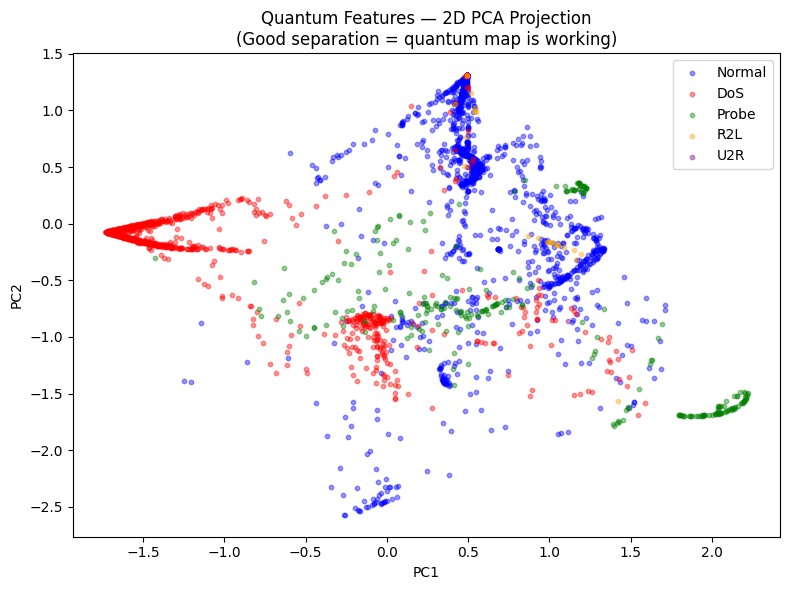

In [40]:
# ============================================================
# Verify quantum features separate classes visually
# If the quantum map is useful, different classes should
# cluster differently in the quantum feature space
# ============================================================

from sklearn.decomposition import PCA as PCA2

pca_vis = PCA2(n_components=2)
X_vis = pca_vis.fit_transform(X_q_train)

plt.figure(figsize=(8, 6))
class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
colors = ['blue', 'red', 'green', 'orange', 'purple']

for cls, name, color in zip(range(5), class_names, colors):
    mask = y_sub == cls
    plt.scatter(X_vis[mask, 0], X_vis[mask, 1],
                label=name, alpha=0.4, s=10, color=color)

plt.title("Quantum Features — 2D PCA Projection\n(Good separation = quantum map is working)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("quantum_feature_space.png", dpi=150)
plt.show()

In [41]:
# ============================================================
# Train classifier on quantum features
# Use Random Forest — robust to feature scale
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Normalise quantum features to [0,1] for fair comparison
feat_scaler = StandardScaler()
X_q_train_sc = feat_scaler.fit_transform(X_q_train)
X_q_test_sc  = feat_scaler.transform(X_q_test)

# Train multiple classifiers on quantum features
results = {}

# 1. Random Forest on quantum features
print("Training Random Forest on quantum features...")
rf_q = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_q.fit(X_q_train_sc, y_sub)
rf_q_pred = rf_q.predict(X_q_test_sc)
rf_q_acc  = accuracy_score(y_test, rf_q_pred) * 100
results['QML + RF'] = rf_q_acc
print(f"  QML + Random Forest: {rf_q_acc:.2f}%")

# 2. SVM on quantum features
print("Training SVM on quantum features...")
svm_q = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_q.fit(X_q_train_sc, y_sub)
svm_q_pred = svm_q.predict(X_q_test_sc)
svm_q_acc  = accuracy_score(y_test, svm_q_pred) * 100
results['QML + SVM'] = svm_q_acc
print(f"  QML + SVM: {svm_q_acc:.2f}%")

# 3. MLP on quantum features
print("Training MLP on quantum features...")
mlp_q = MLPClassifier(hidden_layer_sizes=(64, 32),
                       max_iter=500, random_state=42,
                       early_stopping=True)
mlp_q.fit(X_q_train_sc, y_sub)
mlp_q_pred = mlp_q.predict(X_q_test_sc)
mlp_q_acc  = accuracy_score(y_test, mlp_q_pred) * 100
results['QML + MLP'] = mlp_q_acc
print(f"  QML + MLP: {mlp_q_acc:.2f}%")

Training Random Forest on quantum features...
  QML + Random Forest: 88.42%
Training SVM on quantum features...
  QML + SVM: 88.43%
Training MLP on quantum features...
  QML + MLP: 88.04%


In [42]:
# ============================================================
# Pick best QML result and show full evaluation
# ============================================================

best_qml_name = max(results, key=results.get)
best_qml_acc  = results[best_qml_name]

# Use the best model's predictions
if best_qml_name == 'QML + RF':
    best_pred = rf_q_pred
elif best_qml_name == 'QML + SVM':
    best_pred = svm_q_pred
else:
    best_pred = mlp_q_pred

print(f"\n{'='*55}")
print(f"  Best QML Model: {best_qml_name} — {best_qml_acc:.2f}%")
print(f"{'='*55}")
print(classification_report(y_test, best_pred,
                             target_names=class_names,
                             zero_division=0))

# Save for final chart
qml_acc = best_qml_acc
y_pred_qml = best_pred


  Best QML Model: QML + SVM — 88.43%
              precision    recall  f1-score   support

      Normal       0.84      0.98      0.91     11245
         DoS       0.96      0.90      0.93      8001
       Probe       0.86      0.71      0.78      2157
         R2L       0.72      0.06      0.11      1009
         U2R       0.00      0.00      0.00        38

    accuracy                           0.88     22450
   macro avg       0.68      0.53      0.55     22450
weighted avg       0.88      0.88      0.87     22450



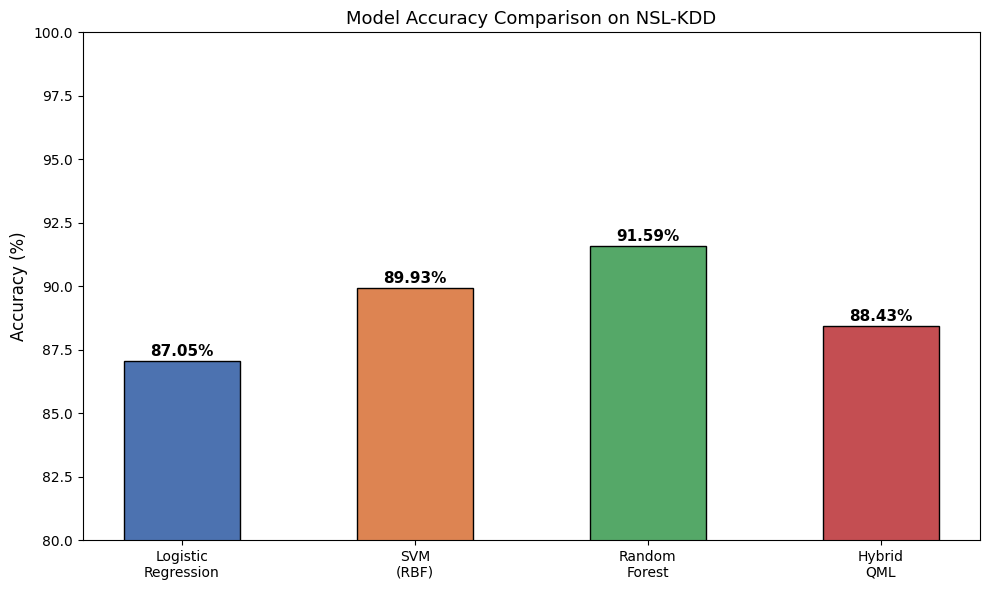

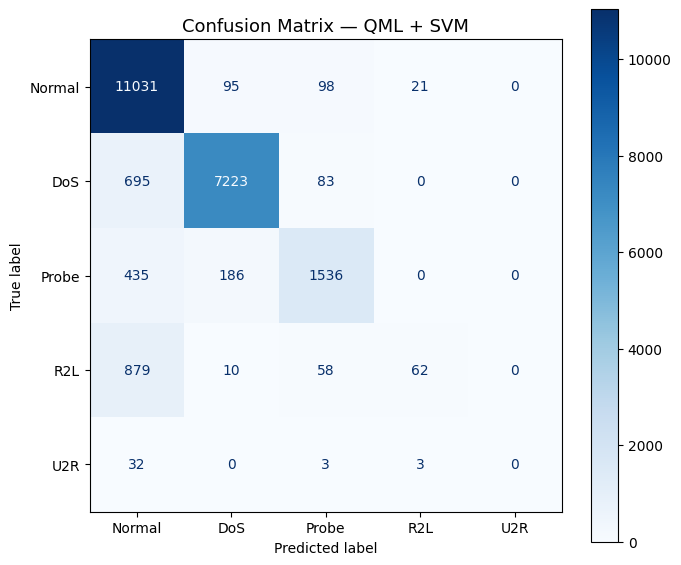


 FINAL RESULTS SUMMARY
  Logistic Regression      : 87.05%
  SVM (RBF)                : 89.93%
  Random Forest            : 91.59% ← BEST
  Hybrid QML               : 88.43%


In [54]:
# ============================================================
# Final comparison chart + confusion matrix
# ============================================================

# --- Accuracy Bar Chart ---
all_results = {
    "Logistic\nRegression": lr_acc,
    "SVM\n(RBF)":           svm_acc,
    "Random\nForest":       rf_acc,
    "Hybrid\nQML":   qml_acc,
}
colors_bar = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(10, 6))
bars = plt.bar(all_results.keys(), all_results.values(),
               color=colors_bar, edgecolor='black', width=0.5)
plt.ylim(80, 100)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison on NSL-KDD", fontsize=13)
for bar, val in zip(bars, all_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{val:.2f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("final_accuracy_comparison.png", dpi=150)
plt.show()

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
cm   = confusion_matrix(y_test, y_pred_qml)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Confusion Matrix — {best_qml_name}", fontsize=13)
plt.tight_layout()
plt.savefig("qml_confusion_matrix.png", dpi=150)
plt.show()

print("\n FINAL RESULTS SUMMARY")
print("="*45)
for name, acc in all_results.items():
    tag = " ← BEST" if acc == max(all_results.values()) else ""
    print(f"  {name.replace(chr(10),' '):25s}: {acc:.2f}%{tag}")

In [44]:
# ============================================================
# PCA Reduction for QSVM
#
# QSVM becomes very expensive with many qubits.
# We reduce:
# 8 features -> 4 features
#
# This means:
# 4 PCA components
# 4 qubits
#
# This is common in QML research papers.
# ============================================================
from sklearn.decomposition import PCA
N_QUBITS_QSVM = 4
# Create new PCA specifically for QSVM
pca_qsvm = PCA(n_components=N_QUBITS_QSVM, random_state=42)
# Fit on TRAIN only
X_train_qsvm = pca_qsvm.fit_transform(X_train_scaled)
X_test_qsvm = pca_qsvm.transform(X_test_scaled)
# Variance retained
var_retained = pca_qsvm.explained_variance_ratio_.sum() * 100
print(" QSVM PCA complete!")
print(f"Features retained : {N_QUBITS_QSVM}")
print(f"Variance retained : {var_retained:.2f}%")
print(f"Train shape : {X_train_qsvm.shape}")
print(f"Test shape : {X_test_qsvm.shape}")

 QSVM PCA complete!
Features retained : 4
Variance retained : 82.15%
Train shape : (125973, 4)
Test shape : (22450, 4)


In [45]:
# ============================================================
# Create smaller subset for QSVM
#
# Quantum kernel computation scales badly:
#   Kernel matrix size = N x N
#
# So we use:
#   1500 training samples
#
# Stratified sampling preserves class ratios.
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np

X_train_qs_sub, _, y_train_qs_sub, _ = train_test_split(
    X_train_qsvm,
    y_train,
    train_size=1500,
    stratify=y_train,
    random_state=42
)

print(" QSVM subset created")
print(f"Subset shape : {X_train_qs_sub.shape}")
print("Class counts:")
print(np.bincount(y_train_qs_sub))

 QSVM subset created
Subset shape : (1500, 4)
Class counts:
[802 547 139  12]


In [46]:
# ============================================================
# Quantum Kernel Circuit
#
# This circuit encodes classical data into quantum states.
#
# Kernel idea:
#   Similar samples -> similar quantum states
#
# Kernel equation:
#   K(x_i, x_j) = |<psi(x_i)|psi(x_j)>|^2
# ============================================================

import pennylane as qml
from pennylane import numpy as pnp

# Quantum device
qsvm_dev = qml.device("default.qubit", wires=N_QUBITS_QSVM)

@qml.qnode(qsvm_dev)
def quantum_feature_map(x):
    """
    Quantum feature embedding.

    Input:
        x -> classical feature vector

    Output:
        quantum state
    """

    # Angle encoding
    for i in range(N_QUBITS_QSVM):
        qml.RY(np.pi * x[i], wires=i)
        qml.RZ(np.pi * x[i], wires=i)

    # Circular entanglement
    for i in range(N_QUBITS_QSVM):
        qml.CNOT(wires=[i, (i + 1) % N_QUBITS_QSVM])

    return qml.state()

print("Quantum feature map defined")

Quantum feature map defined


In [47]:
# ============================================================
# Quantum Kernel Function
#
# Computes fidelity between two quantum states.
#
# Fidelity measures similarity:
#   1.0 -> identical states
#   0.0 -> orthogonal states
# ============================================================

import numpy as np


def quantum_kernel(x1, x2):
    """
    Compute quantum kernel between two samples.
    """

    # Generate quantum states
    psi1 = quantum_feature_map(x1)
    psi2 = quantum_feature_map(x2)

    # Fidelity
    kernel = np.abs(np.vdot(psi1, psi2)) ** 2

    return kernel

print(" Quantum kernel function ready")

 Quantum kernel function ready


In [48]:
# ============================================================
# Build Quantum Kernel Matrices
#
# SVM with precomputed kernel needs:
#
#   TRAIN kernel matrix:
#       K_train[i,j] = kernel(x_i, x_j)
#
#   TEST kernel matrix:
#       K_test[i,j] = kernel(test_i, train_j)
# ============================================================

# ============================================================
# Optimized symmetric TRAIN kernel matrix
# ============================================================

def build_symmetric_kernel_matrix(X, desc=""):
    """
    Build symmetric quantum kernel matrix efficiently.
    """

    n = len(X)
    K = np.zeros((n, n))

    t0 = time.time()

    for i in range(n):

        for j in range(i, n):

            val = quantum_kernel(X[i], X[j])

            K[i, j] = val
            K[j, i] = val

        if (i + 1) % 25 == 0:
            elapsed = time.time() - t0
            print(f"{desc}: {i+1}/{n} rows | {elapsed:.1f}s")

    return K

In [49]:
# ============================================================
# Create SMALLER QSVM subsets for CPU feasibility
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np

# Smaller TRAIN subset
X_train_qs_sub, _, y_train_qs_sub, _ = train_test_split(
    X_train_qsvm,
    y_train,
    train_size=250,
    stratify=y_train,
    random_state=42
)

# Smaller TEST subset
X_test_qs_small = X_test_qsvm[:500]
y_test_qs_small = y_test[:500]

print("Smaller QSVM subsets ready")
print(f"Train subset : {X_train_qs_sub.shape}")
print(f"Test subset  : {X_test_qs_small.shape}")

Smaller QSVM subsets ready
Train subset : (250, 4)
Test subset  : (500, 4)


In [51]:
# ============================================================
# Build TRAIN quantum kernel matrix
# ============================================================

print("Building TRAIN kernel matrix...")

K_train = build_symmetric_kernel_matrix(
    X_train_qs_sub,
    desc="TRAIN"
)

print(" TRAIN kernel matrix complete!")
print(f"K_train shape: {K_train.shape}")

Building TRAIN kernel matrix...
TRAIN: 25/250 rows | 44.1s
TRAIN: 50/250 rows | 74.2s
TRAIN: 75/250 rows | 100.5s
TRAIN: 100/250 rows | 123.7s
TRAIN: 125/250 rows | 142.6s
TRAIN: 150/250 rows | 158.3s
TRAIN: 175/250 rows | 170.6s
TRAIN: 200/250 rows | 179.9s
TRAIN: 225/250 rows | 184.9s
TRAIN: 250/250 rows | 187.2s
 TRAIN kernel matrix complete!
K_train shape: (250, 250)


In [53]:
# ============================================================
# Build TEST quantum kernel matrix
# ============================================================

def build_test_kernel_matrix(X_test, X_train, desc=""):
    """
    Build TEST kernel matrix:
    rows = test samples
    cols = train samples
    """

    K = np.zeros((len(X_test), len(X_train)))

    t0 = time.time()

    for i in range(len(X_test)):

        for j in range(len(X_train)):

            K[i, j] = quantum_kernel(X_test[i], X_train[j])

        if (i + 1) % 25 == 0:
            elapsed = time.time() - t0
            print(f"{desc}: {i+1}/{len(X_test)} rows | {elapsed:.1f}s")

    return K

print("Building TEST kernel matrix...")

K_test = build_test_kernel_matrix(
    X_test_qs_small,
    X_train_qs_sub,
    desc="TEST"
)

print("TEST kernel matrix complete!")
print(f"K_test shape: {K_test.shape}")

Building TEST kernel matrix...
TEST: 25/500 rows | 42.1s
TEST: 50/500 rows | 83.7s
TEST: 75/500 rows | 117.7s
TEST: 100/500 rows | 153.1s
TEST: 125/500 rows | 189.1s
TEST: 150/500 rows | 223.5s
TEST: 175/500 rows | 258.7s
TEST: 200/500 rows | 295.6s
TEST: 225/500 rows | 330.6s
TEST: 250/500 rows | 364.7s
TEST: 275/500 rows | 406.3s
TEST: 300/500 rows | 440.8s
TEST: 325/500 rows | 484.1s
TEST: 350/500 rows | 518.5s
TEST: 375/500 rows | 553.3s
TEST: 400/500 rows | 587.7s
TEST: 425/500 rows | 623.2s
TEST: 450/500 rows | 658.0s
TEST: 475/500 rows | 692.4s
TEST: 500/500 rows | 725.9s
TEST kernel matrix complete!
K_test shape: (500, 250)


 Training QSVM...
 QSVM training complete!
Training time: 0.01s

 Predicting test samples...
Prediction complete!

 QSVM Accuracy: 83.00%

=== Classification Report ===

              precision    recall  f1-score   support

      Normal       0.79      0.98      0.88       252
         DoS       0.91      0.83      0.87       184
       Probe       0.75      0.38      0.50        40
         R2L       0.00      0.00      0.00        24

    accuracy                           0.83       500
   macro avg       0.61      0.55      0.56       500
weighted avg       0.79      0.83      0.80       500



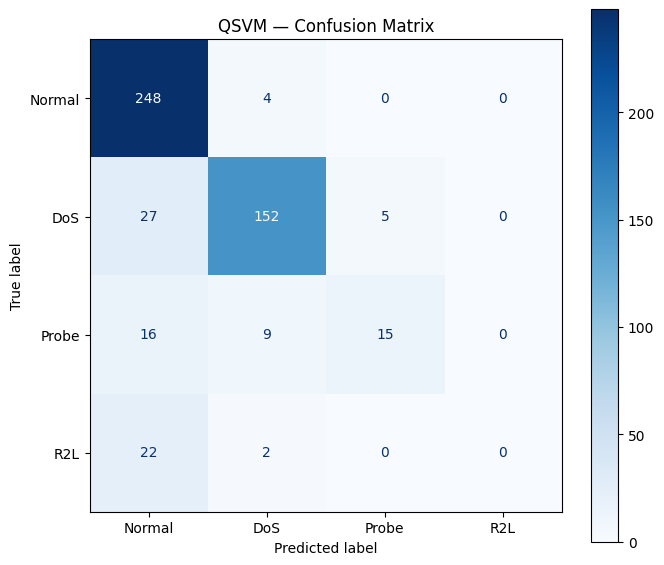

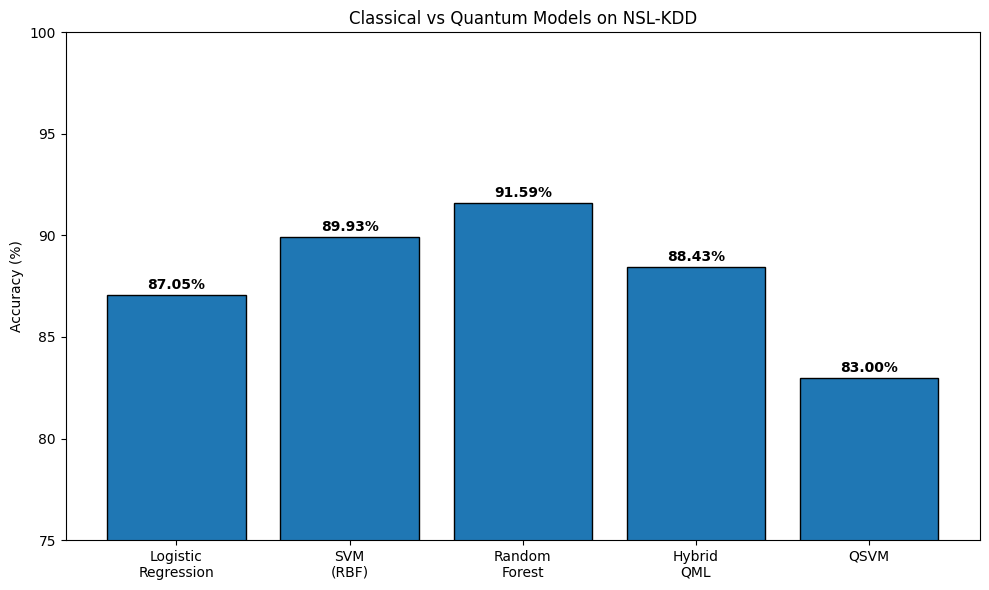


 UPDATED MODEL COMPARISON
Logistic Regression      : 87.05%
SVM (RBF)                : 89.93%
Random Forest            : 91.59% ← BEST
Hybrid QML               : 88.43%
QSVM                     : 83.00%


In [57]:
# ============================================================
# Train and Evaluate QSVM
#
# TRUE Quantum Support Vector Machine using:
#   - Precomputed quantum kernel matrix
#   - Quantum Hilbert-space similarity
#
# This evaluates the REAL QSVM model.
# ============================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import time

# ============================================================
# Train QSVM
# ============================================================

print(" Training QSVM...")

t0 = time.time()

# SVM using precomputed quantum kernel
qsvm_model = SVC(kernel='precomputed')

# Train on quantum kernel matrix
qsvm_model.fit(K_train, y_train_qs_sub)

train_time = time.time() - t0

print(" QSVM training complete!")
print(f"Training time: {train_time:.2f}s")

# ============================================================
# Predict
# ============================================================

print("\n Predicting test samples...")

y_pred_qsvm = qsvm_model.predict(K_test)

print("Prediction complete!")

# ============================================================
# Accuracy
# ============================================================

qsvm_acc = accuracy_score(y_test_qs_small, y_pred_qsvm) * 100

print(f"\n QSVM Accuracy: {qsvm_acc:.2f}%")

# ============================================================
# Dynamic class handling
#
# Small subsets may not contain all 5 classes.
# We therefore detect which classes are present.
# ============================================================

labels_present = sorted(np.unique(y_test_qs_small))

class_names_map = {
    0: 'Normal',
    1: 'DoS',
    2: 'Probe',
    3: 'R2L',
    4: 'U2R'
}

target_names_dynamic = [
    class_names_map[i] for i in labels_present
]

# ============================================================
# Classification Report
# ============================================================

print("\n=== Classification Report ===\n")

print(classification_report(
    y_test_qs_small,
    y_pred_qsvm,
    labels=labels_present,
    target_names=target_names_dynamic,
    zero_division=0
))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test_qs_small,
    y_pred_qsvm,
    labels=labels_present
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names_dynamic
)

disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=True
)

plt.title("QSVM — Confusion Matrix")
plt.tight_layout()
plt.show()

# ============================================================
# Add QSVM to overall comparison
# ============================================================

all_results_updated = {
    "Logistic\nRegression": lr_acc,
    "SVM\n(RBF)": svm_acc,
    "Random\nForest": rf_acc,
    "Hybrid\nQML": qml_acc,
    "QSVM": qsvm_acc,
}

# ============================================================
# Accuracy Comparison Chart
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    all_results_updated.keys(),
    all_results_updated.values(),
    edgecolor='black'
)

plt.ylim(75, 100)

plt.ylabel("Accuracy (%)")
plt.title("Classical vs Quantum Models on NSL-KDD")

# Add accuracy labels above bars
for bar, val in zip(bars, all_results_updated.values()):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{val:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# ============================================================
# Final Summary
# ============================================================

print("\n UPDATED MODEL COMPARISON")
print("=" * 50)

for name, acc in all_results_updated.items():

    tag = " ← BEST" if acc == max(all_results_updated.values()) else ""

    print(f"{name.replace(chr(10), ' '):25s}: {acc:.2f}%{tag}")

